In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

import torch
import torch.nn as nn
import torch.optim as optim

import sklearn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# 데이터를 가져오는 모듈
from torch.utils.data import TensorDataset, DataLoader

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# sklearn.set_config(display="text")

## 캘리포니아 하우징 데이터셋
- 캘리포니아 하우징 데이터셋은 1990년 미국 인구조사 데이터를 기반으로 20,640개 구역의 소득, 건령, 방 개수, 인구수, 지리적 위치(위경도)를 수록한 회귀용 데이터셋입니다.
각 구역의 가구 특성을 바탕으로 해당 지역의 주택 가격 중간값(Target)을 예측하기 위해 활용됩니다.

| 컬럼명 | 한글 설명 | 상세 의미 및 단위 |
| --- | --- | --- |
| MedInc | 중간 소득 | 블록 내 가구들의 중간 소득 (단위: 10,000 달러) |
| HouseAge | 주택 연식 | 블록 내 주택들의 평균 건령 (단위: 년) |
| AveRooms | 평균 방 수 | 가구당 평균 방 개수 |
| AveBedrms | 평균 침실 수 | 가구당 평균 침실 개수 |
| Population | 인구수 | 블록 내 전체 거주 인구수 (단위: 명) |
| AveOccup | 평균 거주자 수 | 가구당 평균 거주 인원수 (단위: 명) |
| Latitude | 위도 | 블록 위치의 위도 좌표 (도) |
| Longitude | 경도 | 블록 위치의 경도 좌표 (도) |
| Target | 주택 가격 (정답) | 블록 내 주택 가격 중간값 (단위: 100,000 달러) |

### 실무에선 항상 train 데이터가 '한번에' 제공되지 않는다.
- 항상 데이터가 추가되거나 불규칙하게 되거나 일정량씩 되거나 하는 경우들이 존재한다.
  데이터 셋이 준비되기까지 모두 기다릴 순 없으므로 아래와 같은 방법으로 방법을 해결해야한다

#### 방법. 1
- 매일 새로이 추가된 데이터를 기존에 데이터에 더해서 훈련하자!
- 단점 : 시간이 지날수록 데이터의 크기가 늘어나는데 훈련시킬 때의 HW, 시간이 커짐
- 비용이 점차 증가하므로, 지속가능한 방법은 아닐 수 있다.

#### 방법. 2
- 새로운 데이터가 추가될 때 마다, 기존데이터를 버리고 새로운 데이터로만 학습
- 단점: 데이터 크기는 유지되겠지만 버리는 데이터가 발생
- 만약 이전에 중요한 데이터가 포함되었을 시 중요한 데이터 학습이 날아간다.

# 점진적 학습(Incremental Learning)
- 위와 같은 문제를 해결하기 위해서 나온 학습기법, 기존의 훈련된 모델을 버리지 않고, 새로운 데이터만 조금씩 더 훈련하는 방법

## 1. 대표적인 점진적 학습 알고리즘 SGD(Stochastic Gradient Descent)
    - Stochastic(확률적): 무작위하게, 랜덤하게
    - Gradient(경사): 기울기
    - Descent(하강): 경사를 따라 내려가는 것
    
- 즉, 훈련세트를 사용해 무언가 내려가는 방향을 찾아가는데, 시작점은 랜덤하게 하나를 골라서 시작하며, 정답이 어떤 것인지 학습하며 배워간다.  
  훈련 데이터 세트 훈련 후 만족한 결과가 나오지 않으면 다시 훈련 시켜 원하는 결과가 나올 때 까지 훈련시킨다. 이 싸이클을 `epoch`라고 한다.

<img src="https://editor.analyticsvidhya.com/uploads/631731_P7z2BKhd0R-9uyn9ThDasA.png" width="700" />


## 2. 에포크(Epoch)
- 모든 훈련데이터 셋을 다 사용하고, 원하는 데이터 결과를 얻지 못하면 다시 훈련시키는 방법
- 한 번 또는 수 차례 진행되며, 각각 데이터 셋을 몇개씩 사용할 수 있는지 정할 수 있다.

### Batch / Minibatch / Stochastic
- Full : 일괄
- Minibatch(가장 많이 사용): 데이터 세트를 토막
- Stochastic: 1개씩

<img src="https://images.velog.io/images/findingflow/post/63e0b41c-060a-43f7-9554-79ce0af40e5e/image.png" src="800">


### 경사 하강법(Gradient Descent)의 3가지 유형과 기울기 위험성
#### 1. 확률적 경사 하강법 (SGD: Stochastic Gradient Descent)
  - 방식: 매 단계마다 '단 1개의 샘플'을 무작위로 추출하여 가중치 업데이트
  - 장점: 연산 속도가 매우 빠르고 메모리 부담이 없음
  - 단점/위험성: 노이즈나 튀는 데이터(Outlier)를 만날 경우 기울기 방향이 엉뚱한 곳으로 크게 진동(Fluctuation)하여 학습이 불안정해짐

#### 2. 미니 배치 경사 하강법 (Mini-batch Gradient Descent) ★ 가장 많이 사용
  - 방식: 전체 데이터를 적절한 크기(예: 32, 64, 128개)의 '묶음(Mini-batch)'으로 나누어 학습 및 업데이트
  - 장점: SGD의 진동을 줄여 안정성을 확보하면서도 배치 경사 하강법보다 연산 속도가 빠름 (GPU 병렬 처리 최적화)
  - 특징: 실무 및 최신 딥러닝에서 표준으로 채택하는 방식

#### 3. 배치 경사 하강법 (Batch Gradient Descent / BGD)
  - 방식: 전체 데이터셋(All Samples)을 한 번에 모두 사용하여 기울기를 구한 뒤 1회 업데이트
  - 장점: 전체 데이터의 평균 기울기를 사용하므로 손실 곡선이 매우 매끄럽고 가장 안정적으로 수렴
  - 단점: 데이터 크기가 크면 RAM/VRAM 메모리 부족(OOM) 현상이 발생하고 1회 업데이트에 걸리는 시간이 매우 오래 걸림

### 경사 하강법 비교 표 
| 구분 | 1회 업데이트에 쓰는 데이터 | 학습 안정성 | 메모리 부담 | 특징 |
|:---:|:---:|:---:|:---:|:---|
| **SGD** | 1개 | 낮음 (심하게 튐) | 매우 적음 | 빠른 속도, 불안정한 경로 |
| **Mini-batch** | N개 (예: 32, 64, 128) | 보통~높음 (안정적) | 적절함 | **딥러닝 실무 표준** |
| **Batch (BGD)** | 전체 데이터 | 매우 높음 (매끄러움) | 매우 큼 | 메모리 한계로 대용량에 불가 |

<img src="https://miro.medium.com/v2/resize:fit:908/1*bKSddSmLDaYszWllvQ3Z6A.png" src="500" />

## 1.데이터 준비 

In [9]:
housing = fetch_california_housing()
print(housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [10]:
housing_df = pd.DataFrame(
    data=housing.data,
    columns=housing.feature_names
)

housing_df["Target"] = housing.target

In [11]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [15]:
X = housing_df.drop("Target", axis=1)
X.head

<bound method NDFrame.head of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Lo

In [17]:
y = housing_df["Target"]
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Target, dtype: float64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(16512, 8) (4128, 8) (16512,) (4128,)


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 파이토치의 텐서로 형변환 

In [ ]:
# 순전파 , 역전파 
# 자동으로 한차원 늘리기 -> 차수늘리기

In [21]:
# .unsqueeze(1)
# 브로드 캐스팅으로 확정되어 버리는 것을 방지하기 위해 차수를 맞춤 
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

print(X_test_scaled.shape, y_test_tensor.shape)
print(X_train_scaled.shape, y_train_tensor.shape)

(4128, 8) torch.Size([4128])
(16512, 8) torch.Size([16512])


## TensorDataret
- 하나의 세트 (set)로 묶어주는 포장지 역할

In [23]:
train_darset = TensorDataset(X_train_tensor, y_train_tensor)
trest_darset = TensorDataset(X_test_tensor, y_test_tensor)


## 데이터 로더(DataLoader) - 미니배치(64)
- 데이터 로더는 대용량 데이터를 효율적으로 관리하고, 모델 학습 과정에서 데이터를 안전하고 빠르게 공급해 주는 핵심 도구입니다.
- 대용량 데이터를 한 번에 메모리에 올리지 않고, 모델이 학습할 수 있는 적당한 크기(Batch)로 나누어 효율적으로 공급합니다.
- 데이터가 특정 순서에 오염되지 않도록 섞어주는 셔플링, 데이터 양을 늘려주는 증강, 로딩 속도를 높이는 병렬 처리 기능을 제공합니다.
- 학습과 평가 시 일관된 방식으로 데이터를 제공하며, 대표적으로 PyTorch의 DataLoader, TensorFlow의 tf.data API를 통해 쉽게 구현할 수 있습니다.

### 데이터 로더의 주요 기능
- 배치 분할: 대규모 데이터셋을 모델이 한 번에 학습할 수 있는 적당한 크기(Batch Size)로 나누어 메모리 과적합를 방지합니다.
- 데이터 셔플링: 모델이 데이터의 입력 순서를 외우지 못하도록 매 에포크마다 무작위로 순서를 섞어 학습 성능을 높입니다.
- 멀티프로세싱 및 병렬 처리(num_workers): CPU와 GPU가 동시에 작업할 수 있도록 데이터를 병렬로 미리 준비하여 학습 속도 지연을 줄입니다.
- 일관된 데이터 전처리: 학습과 평가 단계 모두에서 데이터 증강, 데이터 정규화 등을 동일하고 일관된 방식으로 적용합니다.

In [25]:
# 4배수로 함 

train_loader = DataLoader(train_dataset, batch_size=64,shuffle=True,  drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=64,shuffle=Felse)


NameError: name 'train_dataset' is not defined

In [44]:
# list(train_loader)[0]
batch_X, batch_y = next(iter(train_loader))

print(batch_X.shape, batch_X.shape)

torch.Size([64, 8]) torch.Size([64, 8])


## 2딘계 , 모델 준비


In [45]:
# ⭐️
# nn.Linear(입력(특성개수), 출력(결과의 개수))
        # nn : 머신러닝을 해주는 모델 
model= nn.Linear(8, 1)

        # 얼마나 떨어져 있는지 구하기 위해 들어가야됌  
# 손실 함수 
criterion = nn.MSELoss()  

        # 최적의 기울기의 알맞는 선상으로 바꿔주는 모듈 
# 손실 함수가 계산 했던 잔차(오차)를 최소한으로 줄이는 방향으로 가중치와 편향을 업데이트 시켜주는 모듈 
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# loss 잔차 


In [36]:
"""
[이진 분류(Binary Classification) 손실 함수 개념 및 연산 순서]

■ 기본 전제
  - 모델의 예측값(p)은 '양성 클래스(1)'일 확률을 의미합니다.
  - 손실(Loss)은 정답을 맞힐수록 0에 가깝고, 크게 틀릴수록 기하급수적으로 커지는 양수여야 합니다.

■ 연산 순서 (BCE Loss 계산 3단계)

  1단계) '정답 클래스 기준'의 확률(y_true) 추출하기
    - 정답 = 1 (양성) : 모델의 예측 확률(p) 그대로 사용
    - 정답 = 0 (음성) : 반전된 확률 (1 - p) 사용
    
    * 예시 A (예측 0.9 / 정답 1) ➔ 정답 확률 = 0.9 (잘 맞힘)
    * 예시 B (예측 0.3 / 정답 1) ➔ 정답 확률 = 0.3 (못 맞힘)
    * 예시 C (예측 0.2 / 정답 0) ➔ 정답 확률 = 1 - 0.2 = 0.8 (잘 맞힘)
    * 예시 D (예측 0.8 / 정답 0) ➔ 정답 확률 = 1 - 0.8 = 0.2 (못 맞힘)

  2단계) 추출한 확률값에 '자연로그(ln)' 취하기
    - 확률값(0~1)에 로그를 씌우면 결과는 항상 '0 이하의 음수'가 됩니다.
    - 정답을 맞힐수록 0에 수렴하고, 틀릴수록(확률이 0에 가까울수록) 음의 무한대(-∞)로 폭발합니다.
    
    * 예시 A (0.9) ➔ ln(0.9)  ≈ -0.105 (약한 음수)
    * 예시 B (0.3) ➔ ln(0.3)  ≈ -1.204 (큰 음수)
    * 예시 C (0.8) ➔ ln(0.8)  ≈ -0.223 (약한 음수)
    * 예시 D (0.2) ➔ ln(0.2)  ≈ -1.609 (큰 음수)

  3단계) 마이너스(-)를 곱해 최종 손실값 '양수화'하기
    - 로그 연산 결과(음수)에 마이너스를 취하여 사람이 직관적으로 이해할 수 있는 양수 벌점(Loss)으로 바꿉니다.
    
    * 예시 A ➔ -ln(0.9) = +0.105 (낮은 손실: 정답을 잘 맞힘)
    * 예시 B ➔ -ln(0.3) = +1.204 (높은 손실: 정답을 못 맞힘)
    * 예시 C ➔ -ln(0.8) = +0.223 (낮은 손실: 정답을 잘 맞힘)
    * 예시 D ➔ -ln(0.2) = +1.609 (높은 손실: 정답을 못 맞힘)

■ 결론 (Binary Cross Entropy 공식)
  Loss = - [ y * ln(p) + (1 - y) * ln(1 - p) ]
  - y = 1 일 때 : -ln(p)
  - y = 0 일 때 : -ln(1 - p)
"""

None

## 3단계 , 모델 학습


In [46]:
model.train()

# 1eplch
epoch_loss = 0

for X_bech, y_bech in train_loader:
    # 미니배치 마다 반복
    optimizer.zero_grad() # 기울기 초기화
    prediction = model(betch_X) # 순전파
    loss = criterion(prediction, betch_X) # 손실 계산 
    loss.backward() # 역전파 
    optimizer.step() # 가증치 업데이트 

    epoch_loss+= loss.item()

avg_loss = epoch_loss / len(train_loader)
print(f"1 Epoch 학습 완료 - 평균 loss: {avg_loss:.4f}")
    

NameError: name 'betch_X' is not defined

In [47]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.1638,  0.1245, -0.2968,  0.0600,  0.2600, -0.2445, -0.1477, -0.3397]],
        requires_grad=True),
 Parameter containing:
 tensor([0.3489], requires_grad=True)]

In [49]:

# 학습 
epochs = 100

model.train()

for epoch in range(epochs):
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() # 가중치 초기화
        prediction = model(X_batch) # out 예측값 (순전파)
        loss = criterion(prediction, y_batch) # 손실 함수로 잔차를 구함
        loss.backward() # 역전파(기울기)
        optimizer.step() # 모델 파라미터 업데이트

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch + 1}/{epochs} - Loss: {avg_loss:.4f}")

/opt/anaconda3/envs/machine_learning/lib/python3.12/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 10/100 - Loss: 1.3414
Epoch: 20/100 - Loss: 1.3415
Epoch: 30/100 - Loss: 1.3414
Epoch: 40/100 - Loss: 1.3414
Epoch: 50/100 - Loss: 1.3414
Epoch: 60/100 - Loss: 1.3414
Epoch: 70/100 - Loss: 1.3414
Epoch: 80/100 - Loss: 1.3415
Epoch: 90/100 - Loss: 1.3412
Epoch: 100/100 - Loss: 1.3414


## 4단계 , 모델 평가 

In [50]:
# 파라미터 업데이트를 하지 않음 
model.eval()
test_loss = 0.0

with toch np_grad(0:
    for X_bech, y_batch in test_loader:
        prediction = model(X_batch)
        loss = criterion(prediction, y_batch)
        test_loss += loss.item()

avg_test_loss = test_loss /len
print(f""0

Linear(in_features=8, out_features=1, bias=True)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [ ]:
# 4.526
scaled = scaler.transform([[8.3252, 41.0, 6.984127, 1.023810, 322.0, 2.555556, 37.88, -122.23]])
print(scaled)
new_data = torch.tensor(scaled, dtype=torch.float32)

model.eval()

with torch.no_grad():
    pass
    prediction = model(new_data)
    print(f"집값 예측(단위: 100,000 달러): {prediction}")

# 손 글씨 숫자 데이터 셋
- 사이킷런(scikit-learn) 내장 데이터셋으로, MNIST 손글씨를 8x8 픽셀 크기로 축소한 버전입니다.
- 8x8 이미지의 픽셀을 한 줄로 펼쳐 64개의 숫자로 이루어진 '64차원 벡터'로 표현합니다.
- 데이터 크기가 매우 작아 1,797개 복잡한 AI 알고리즘 없이 기초적인 머신러닝 모델을 빠르게 테스트할 때 쓰입니다.

## 손글씨 데이터 컬럼
| 키 (Key/Column) | 데이터 타입 | 데이터 형태 (Shape) | 설명 |
| :--- | :--- | :--- | :--- |
| **`data`** | `ndarray` (float64) | `(1797, 64)` | 모델 학습에 사용되는 **입력 데이터**입니다. 8x8 픽셀 이미지를 1차원으로 길게 펼친 64개의 특징(Feature) 값이 1,797개 들어 있습니다. |
| **`target`** | `ndarray` (int64) | `(1797,)` | 모델이 맞춰야 하는 **정답(라벨) 데이터**입니다. 각 이미지에 해당하는 숫자(0~9)가 매칭되어 있습니다. |
| **`feature_names`** | `list` (str) | `64개 항목` | `data`의 64개 열이 어떤 픽셀을 의미하는지 나타내는 이름입니다. 행과 열을 기준으로 `pixel_0_0`부터 `pixel_7_7`까지 명명되어 있습니다. |
| **`target_names`** | `ndarray` (int64) | `(10,)` | 정답이 클래스로서 가질 수 있는 실제 값의 종류인 `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`를 의미합니다. |
| **`images`** | `ndarray` (float64) | `(1797, 8, 8)` | `data`와 동일한 픽셀 값이지만, 펼치지 않고 **원본 8x8 행렬 형태**를 유지한 데이터입니다. `matplotlib` 등으로 시각화할 때 주로 씁니다. |
| **`DESCR`** | `str` | 텍스트 원문 | 데이터셋의 출처, 데이터 수집 방식, 픽셀 값 범위(0~16) 등 데이터셋에 대한 **상세한 설명(Description)**이 담긴 영문 텍스트입니다. |
| **`frame`** | `NoneType` 또는 `DataFrame` | 변동 가능 | 데이터를 판다스(Pandas)의 DataFrame 구조로 불러오지 않았다면 기본적으로 `None`으로 표시됩니다. |

In [57]:
digits = load_digits()
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [64]:
X = digits["data"]
y = digits["target"]

print(X)
print(y)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
[0 1 2 ... 8 9 8]


In [65]:
print(X.shape, y.shape)

(1797, 64) (1797,)


NameError: name 'flatten' is not defined

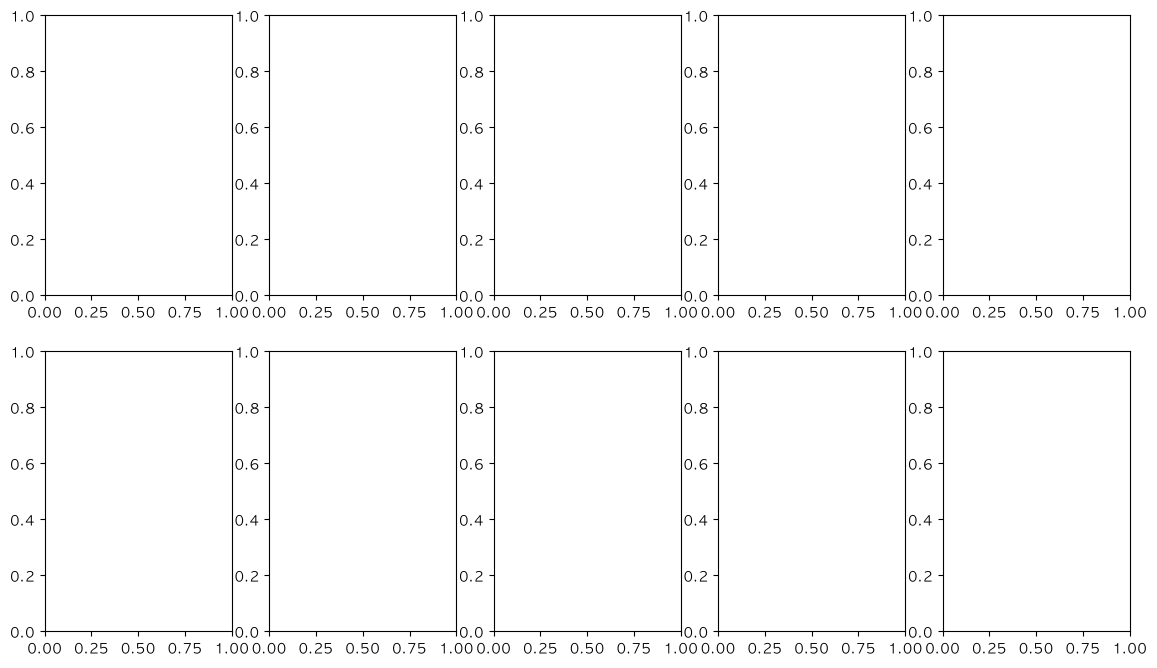

In [69]:
fig , axes = plt.subplots(nrows=2, ncols=5, figsize=(14, 8))

for i, ax in enumerate(axes, flatten()):
    ing_data = X[i].reshape((8, 8))
    # print(ing_data)

    # sns.heatmap(img_data, cmap="gray", char=False, ax=ax)
    sns.heatmap(img_data, cmap="gray_r", char=False, ax=ax, xticklabels=False, yticklabels=False)

In [79]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_test.shape, X_train.shape, y_test.shape, y_train.shape)

(1437, 64) (360, 64) (1437,) (360,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2026
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32) / 16.0
X_test_tensor = torch.tensor(X_test, dtype=torch.float32) / 16.0

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

## 표준화 또는 정규화 


In [75]:
# 정규화
# MinMaxScaler
# 표준화 
# StandardScaler
X_train_tensorn = torch.tensor(X_train, dtype= torch.float) / 16.0
X_train_tensorn = torch.tensor(X_train, dtype= torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.float) / 16.0
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [76]:
print(X_train_tensor)

tensor([[-0.5677,  0.1863, -0.1416,  ..., -0.0524,  0.9652, -1.2870],
        [-0.1074, -1.0058, -0.4029,  ...,  0.0870, -0.6200,  0.5459],
        [ 0.5984, -1.5622,  0.4931,  ..., -0.0082, -0.5965,  1.1253],
        ...,
        [ 1.0138,  0.0273,  0.3792,  ..., -0.0048,  0.6416, -1.2121],
        [ 0.3928, -0.6085, -0.5658,  ..., -0.1117, -0.7654,  0.5909],
        [ 0.4729, -0.7674,  0.3568,  ..., -0.0335,  0.5665, -0.1033]])


In [78]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

AssertionError: Size mismatch between tensors

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2026
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float) / 16.0
X_test_tensor = torch.tensor(X_test, dtype=torch.float) / 16.0

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [86]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [87]:
train_loader = DataLoader(train_darset, batch_size=64, shuffle=True) 
test_loader = DataLoader(train_darset, batch_size=64, shuffle=False )

img, labels = next(iter(train_loader))
print(img, labels)

tensor([[-5.5302e-01,  4.2472e-01, -5.3352e-01, -1.7158e-02,  2.5857e-01,
          7.1550e-02, -8.5447e-01,  8.5058e-01],
        [ 1.5304e+00,  3.4524e-01,  6.8747e-01, -1.1253e-01,  5.3871e-01,
         -2.5287e-02, -6.7626e-01,  4.6601e-01],
        [-2.5370e-02,  5.0419e-01,  6.2593e-02, -3.7460e-02, -2.7713e-01,
          9.2902e-02, -7.4661e-01,  8.1063e-01],
        [ 4.5499e-01, -1.8006e+00,  2.5836e-01, -2.7821e-01, -4.0623e-01,
         -2.7645e-03,  5.2901e-01, -6.3393e-02],
        [-6.3744e-02, -1.9596e+00,  1.1494e-01,  9.4687e-02,  4.6004e+00,
         -4.6581e-02, -1.1265e+00,  1.1303e+00],
        [-1.0482e+00, -5.2137e-02, -1.0088e+00, -4.7461e-02,  9.8396e-01,
          2.2182e-02, -7.1847e-01,  6.2084e-01],
        [ 1.6089e+00, -7.6742e-01,  8.0648e-01, -2.3229e-01,  1.3967e+00,
         -7.8600e-04,  7.5412e-01, -1.1522e+00],
        [ 1.3268e+00, -1.1648e+00,  4.2772e-01, -2.2444e-01, -2.6396e-01,
          1.5001e-02,  1.1856e+00, -1.5267e+00],
        [-3.7310

In [88]:
print(img.size(), labels.size())

torch.Size([64, 8]) torch.Size([64])


In [89]:
model = nn.Sequential(
    nn.Linear(64, 10)  # 레이어 하나 쌓일때는 머신러닝 
    
)
model

Sequential(
  (0): Linear(in_features=64, out_features=10, bias=True)
)

In [91]:
# 무작위로 초기화된 가중치와 편향 
list(model.parameters())

[Parameter containing:
 tensor([[ 9.9034e-02,  7.2123e-02,  1.2147e-01,  3.3048e-02, -4.3233e-02,
          -9.2948e-02, -8.5164e-02,  1.2067e-01,  1.1243e-01, -8.6636e-03,
          -9.9792e-02,  9.5600e-02, -1.0978e-01,  1.1909e-01,  7.9262e-02,
           4.2452e-02,  4.3226e-02,  9.2059e-02,  1.1708e-01, -5.2430e-02,
           6.5371e-02,  5.1571e-02,  2.0616e-02,  1.1424e-01,  2.5250e-02,
          -9.5487e-02,  1.1409e-02, -3.6369e-02,  5.2275e-02, -8.1304e-04,
           5.3339e-02, -4.9992e-02,  1.2314e-01,  6.4958e-02, -7.8750e-02,
          -1.1327e-01, -1.0716e-01, -5.4702e-02,  9.4297e-02, -7.5361e-02,
           6.0784e-02, -9.9132e-02,  1.1276e-01,  9.8284e-02, -1.0909e-01,
          -7.7947e-02, -9.8555e-02,  2.7099e-03,  3.0010e-02,  2.1031e-02,
           3.2045e-02,  1.1523e-01, -5.9318e-02,  7.8601e-02, -6.8829e-02,
           7.8960e-02,  1.1598e-01,  1.0194e-01,  1.0628e-01,  2.9912e-03,
          -5.2313e-02,  4.2621e-02, -6.1719e-02, -3.6717e-02],
         [-4.0

## Adam
- 역전파로 계산된 기울기를 바탕으로 파라미터(Weight, Bias)를 업데이트하는 `최적화 알고리즘(Optimizer)`
- 하이퍼파라미터(학습률 등)를 크게 수정하지 않아도 기본값으로 좋은 결과를 냅니다

In [124]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [125]:
epochs = 50

for epoch in range(epochs):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # 기울기 초기화

        y_pred = model(X_batch)  # 순전파
        loss  = criterion(y_pred, y_batch)  # 손실계산 
        loss.backward()  # 역전파 
        optimizer.step() # 가중치 업데이트

        sum_losses += loss.item()

        # 정확도 계산
        y_pred_index = y_pred.argmax(dim=1)  # 2차원 데이터 
        acc = (y_batch == y_pred_index).float().mean().item() * 100   # 1차원 데이터 
        sum_accs +=  acc

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)

    print(f"Epoch:{epoch + 1}/{epoch} | Train  loss : {avg_train_loss:.4f},Train Acc: {avg_train_acc:.2f}%")

Epoch:1/0 | Train  loss : 0.4073,Train Acc: 93.79%
Epoch:2/1 | Train  loss : 0.4007,Train Acc: 93.39%
Epoch:3/2 | Train  loss : 0.3852,Train Acc: 93.86%
Epoch:4/3 | Train  loss : 0.3753,Train Acc: 93.93%
Epoch:5/4 | Train  loss : 0.3647,Train Acc: 93.86%
Epoch:6/5 | Train  loss : 0.3566,Train Acc: 93.93%
Epoch:7/6 | Train  loss : 0.3468,Train Acc: 94.21%
Epoch:8/7 | Train  loss : 0.3386,Train Acc: 94.14%
Epoch:9/8 | Train  loss : 0.3312,Train Acc: 94.23%
Epoch:10/9 | Train  loss : 0.3267,Train Acc: 94.27%
Epoch:11/10 | Train  loss : 0.3203,Train Acc: 94.18%
Epoch:12/11 | Train  loss : 0.3118,Train Acc: 94.43%
Epoch:13/12 | Train  loss : 0.3109,Train Acc: 94.09%
Epoch:14/13 | Train  loss : 0.2997,Train Acc: 94.21%
Epoch:15/14 | Train  loss : 0.2964,Train Acc: 94.46%
Epoch:16/15 | Train  loss : 0.2897,Train Acc: 94.62%
Epoch:17/16 | Train  loss : 0.2855,Train Acc: 94.54%
Epoch:18/17 | Train  loss : 0.2792,Train Acc: 94.47%
Epoch:19/18 | Train  loss : 0.2773,Train Acc: 94.61%
Epoch:20/19 

In [98]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)




epochs = 50

for epoch in range(epochs):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() # 기울기 초기화
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch) # 손실 계산
        loss.backward() # 역전파
        optimizer.step() # 가중치 업데이트

        sum_losses += loss.item() 

        # 정확도 계산
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)

    print(f"Epoch: {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.2f}%")

Epoch: 1/50 | Train Loss: 2.2401, Train Acc: 13.59%
Epoch: 2/50 | Train Loss: 2.1074, Train Acc: 40.27%
Epoch: 3/50 | Train Loss: 1.9920, Train Acc: 62.48%
Epoch: 4/50 | Train Loss: 1.8803, Train Acc: 71.98%
Epoch: 5/50 | Train Loss: 1.7778, Train Acc: 76.42%
Epoch: 6/50 | Train Loss: 1.6804, Train Acc: 80.85%
Epoch: 7/50 | Train Loss: 1.5892, Train Acc: 82.92%
Epoch: 8/50 | Train Loss: 1.5082, Train Acc: 83.67%
Epoch: 9/50 | Train Loss: 1.4302, Train Acc: 86.40%
Epoch: 10/50 | Train Loss: 1.3571, Train Acc: 87.13%
Epoch: 11/50 | Train Loss: 1.2921, Train Acc: 87.14%
Epoch: 12/50 | Train Loss: 1.2311, Train Acc: 88.33%
Epoch: 13/50 | Train Loss: 1.1734, Train Acc: 88.82%
Epoch: 14/50 | Train Loss: 1.1237, Train Acc: 88.73%
Epoch: 15/50 | Train Loss: 1.0742, Train Acc: 89.09%
Epoch: 16/50 | Train Loss: 1.0244, Train Acc: 90.15%
Epoch: 17/50 | Train Loss: 0.9847, Train Acc: 89.85%
Epoch: 18/50 | Train Loss: 0.9440, Train Acc: 89.74%
Epoch: 19/50 | Train Loss: 0.9100, Train Acc: 90.18%
Ep

In [105]:
model.eval()

test_loss = 0.0
test_acc = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        y_test_pred = model(X_batch)
        loss = criterion(y_test_pred, y_batch)
        test_loss += loss.item()
        
        y_test_index = y_test_pred.argmax(dim=1)
        acc = (y_batch == y_test_index).float().mean().item() * 100
        test_acc += acc

avg_test_loss = test_loss / len(test_loader)
avg_test_acc = test_acc / len(test_loader)

print(f"최종 test 결과 | loss {avg_test_loss:.4f},Accuracy: {avg_test_acc:.2f}%")

최종 test 결과 | loss 0.4287,Accuracy: 94.53%


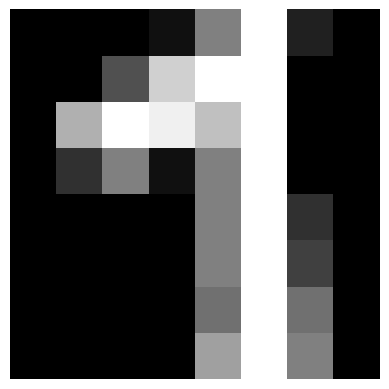

In [107]:
plt.imshow(X_test[0].reshape((8,8)), cmap="gray")
plt.axis("off")
plt.show()

In [108]:
model.eval()

X_test_batch, y_test_batch = next(iter(test_loader))


In [110]:
with torch.no_grad():
    y_pred_batch = model(X_test_batch)
print(y_pred_batch[0])
print(y_pred_batch[0].argmax())
# 로짓 

tensor([-1.1455,  0.6382, -1.7302,  0.2213, -1.8620, -1.4603, -2.3659, -2.5893,
        -0.3805,  1.7106])
tensor(9)


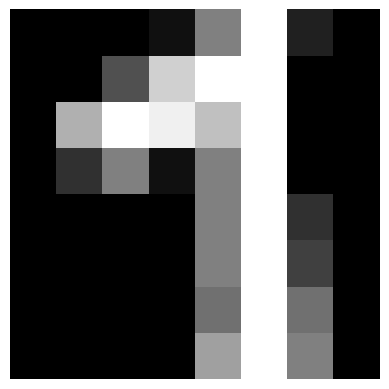

In [113]:
plt.imshow(X_test_batch[0].reshape((8, 8)),cmap="gray")
plt.axis("off")
plt.show()

## 소프트 맥스(softmax)
- 소프트맥스 함수는 모델이 출력한 제한 없는 원시 점수(Logit)들에 지수함수를 취해 모두 양수로 만든 뒤 전체 합으로 나누어 주는 함수입니다.
이를 통해 모든 클래스의 출력값을 0과 1 사이의 값으로 변환하고 총합을 `1(100%)`로 맞춰, 사람이 직관적으로 이해할 수 있는 확률 형태로 다듬어 줍니다

In [114]:
softmax =  nn.Softmax(dim=1)
softmax =  nn.Softmax(1)

In [116]:
y_proba = softmax(y_pred_batch)
# print(y_proba)
print(y_proba[0])

tensor([0.0306, 0.1819, 0.0170, 0.1199, 0.0149, 0.0223, 0.0090, 0.0072, 0.0657,
        0.5315])


In [121]:
pred_label = y_proba[0].argmax().item()
true_label = y_test_batch[0].item()

print(pred_label)
print(true_label)
                  

9
1


In [123]:
for i in range(10):
    print(f"숫자 {i}일 확률 :{y_proba[0][i]:.2f}%")

숫자 0일 확률 :0.03%
숫자 1일 확률 :0.18%
숫자 2일 확률 :0.02%
숫자 3일 확률 :0.12%
숫자 4일 확률 :0.01%
숫자 5일 확률 :0.02%
숫자 6일 확률 :0.01%
숫자 7일 확률 :0.01%
숫자 8일 확률 :0.07%
숫자 9일 확률 :0.53%


In [127]:
model.eval()

test_loss = 0.0
test_acc = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_test_pred = model(X_test_pred, y_batch)
        test_loss += loss.item()

        y_test_index = y_test_pred.argmax()
        acc = (y_batch == y_test_index).float().mean().item() * 100
        test_acc += acc

avg_test_loss = test_loss / len(test_loader)
avg_test_acc = test_acc / len(test_loader)

print(f"최종 test 결과 | loss: {avg_test_loss:.4f} | Accuracy:{avg_test_acc:.2f}%")

NameError: name 'X_test_pred' is not defined

In [ ]:
z